In [1]:
from utils import *

In [2]:
EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3

E_osc = 3

qubit_level = 8
osc_level = 50

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
# plot_specturum(qbt, osc, hilbertspace)

max overlap^2 0.015315063260411915 below threshold for dressed state 148 with eval 66.01994392158106


In [3]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )


amp = 0.0035
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *amp * cos

t_stop = 250 
def square_cos_with_ring_down(t,*args):
    if t > t_stop:
        return 0
    else:
        cos = np.cos(w_d * 2*np.pi * t)
        return  2*np.pi *amp * cos


H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos_with_ring_down]]

kappa = 0.07
decay_term = kappa*a

tot_time = 1000
tlist = np.linspace(0, tot_time, tot_time)[::4]



state_0_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(1,0)])
state_1_dressed = qutip.basis(hilbertspace.dimension, product_to_dressed[(2,0)])
state_plus_dressed = (state_0_dressed + 1j * state_1_dressed).unit()
state_minus_dressed = (state_0_dressed - state_1_dressed).unit()

initial_states  = [state_0_dressed,state_1_dressed,state_plus_dressed,state_minus_dressed ]

# existing_chunk_num = 0
# for ini_state in initial_states:
#     existing_chunk_num = pack_mcsolve_chunks(H = H_with_drive,
#                     state0 = ini_state,
#                     tlist = tlist,
#                     c_ops  = [decay_term],
#                     ntraj = 500,
#                     existing_chunk_num = existing_chunk_num,
#                     chunk_size = 4)

# def pack_pkl_files_to_zip(zip_filename="mcsolve_input.zip"):
#     # Create a new ZIP file
#     with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         # Loop through all files in the current directory
#         for filename in os.listdir('.'):
#             # Check if the file is a .pkl file with an integer name
#             name, ext = os.path.splitext(filename)
#             if ext == '.pkl' and name.isdigit():
#                 # Add the file to the ZIP
#                 zipf.write(filename)
#                 # Delete the .pkl file
#                 os.remove(filename)
                
# pack_pkl_files_to_zip()

# Average results

In [4]:

# List of zip files containing the results
zip_files = [f"mcsolve_result_0.07_d0.0035_tomo_no_drive_at_all/result_{i}.zip" for i in range(500)]

# Divide the files into four equal parts
n_parts = 4
part_length = len(zip_files) // n_parts
zip_file_parts = [zip_files[i * part_length: (i + 1) * part_length] for i in range(n_parts)]

# Initialize an empty list to store the four results
results = []

# Merge the results for each part and append to the results list
for part in zip_file_parts:
    results.append(merge_results(part))


done:125/125


In [5]:
# Delete the file if it already exists
file_path = 'mcsolve_result_0.07_d0.0035_tomo_no_drive_at_all/averaged.pkl'
if os.path.exists(file_path):
    os.remove(file_path)

# Now write to the file
with open(file_path, 'wb') as f:
    pickle.dump(results, f)

In [4]:
import pickle

with open('mcsolve_result_0.07_d0.0035_tomo_no_drive_at_all/averaged.pkl', 'rb') as f:
    results = pickle.load(f)

In [32]:
interactive_heatmap(results[2], product_to_dressed, qubit_level, osc_level)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=249), Output(…

# 1. Partial trace out qubit, truncate to 2 level

In [6]:

tasks = [(results, 
          f'mcsolve_result_0.07_d0.0035_tomo_no_drive_at_all/res_{i}_state_{j}.pkl',
          i, j,  product_to_dressed, qubit_level, osc_level, 1, 2) 
         for i in range(len(results)) 
         for j in range(len(results[i].states))]

from multiprocessing import Pool

with Pool(processes=6) as pool:
    pool.map(compute_and_store_2_level_dm, tasks)

# 2 optimize a phase on the final state and get qutip fidelity for each initial states

In [7]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
              one,
              (zero + 1j * one).unit(),
              (zero - one).unit() ]


num_initial_states = len(results)
num_time_steps = len(results[0].times)
two_level_states = []
for i in range(num_initial_states) :
    two_level_states.append([])
    for j in range(num_time_steps):
        with open(f'mcsolve_result_0.07_d0.0035_tomo_no_drive_at_all/res_{i}_state_{j}.pkl', 'rb') as f:
            state = pickle.load(f)
        two_level_states[-1].append(state)


Text(0.5, 0, 'ns')

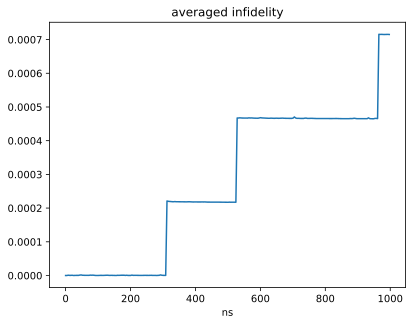

In [8]:


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*dm_ideal))

    return 1-sum(fid)/len(fid)
    




from scipy.optimize import minimize

infidelity = []
phase = []
for idx in range(num_time_steps):
    dms = [states[idx] for states in two_level_states]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)


plt.plot(results[0].times,infidelity)
plt.title("averaged infidelity")
plt.xlabel("ns")

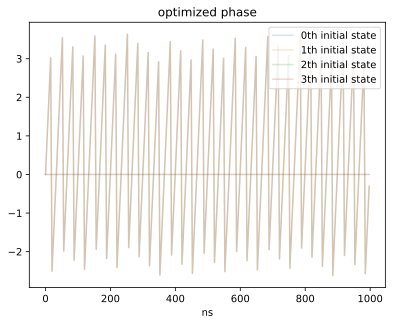

In [12]:
def calc_fidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    return 1-qutip.fidelity(dm, gate*state_ideal)

    

phases = []
for i, states in enumerate(two_level_states):
    phases.append([])
    for idx in range(num_time_steps):
        dm = states[idx]
        def objective_function(params):
            return calc_fidelity_with_phase(params[0], dm, states_ideal[i])
        initial_phase = [0.0]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        phases[-1].append(opt_result.x)

for i in range(4):
    plt.plot(results[0].times,phases[i],label = f'{i}th initial state',alpha = 0.2)
plt.title("optimized phase")
plt.xlabel("ns")
plt.legend()